In [ ]:
📩 SMS Spam Detection Using Machine Learning

In [1]:
#Import libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset  
df=pd.read_csv(r"C:\Users\ladwa\Desktop\New folder (10)\spam.csv",encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df=df[["v1","v2"]]

In [5]:
df.columns=["label","message"]

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
#Check shape
df.shape

(5572, 2)

In [8]:
#check null values
df.isnull().sum()

label      0
message    0
dtype: int64

In [9]:
#check duuplicates
df.duplicated().sum()

403

In [10]:
df=df.drop_duplicates()

In [11]:
df.duplicated().sum()

0

In [33]:
df["label"].value_counts()

label
1    4516
0     653
Name: count, dtype: int64

In [12]:
#label Distribution
label_dis=df["label"].value_counts()

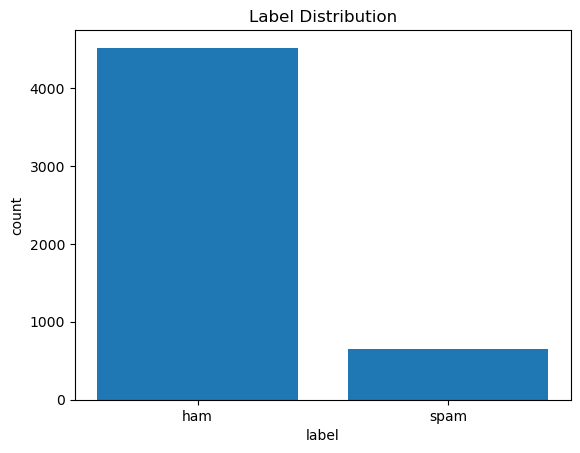

In [13]:
#check distribution using graph
plt.bar(label_dis.index,label_dis.values)
plt.xlabel("label")
plt.ylabel("count")
plt.title("Label Distribution")
plt.show()

In [14]:
#Text Processing
df["message"]=df["message"].str.lower().str.strip()

In [15]:
df["label"]=df["label"].map({"ham":1,"spam":0})

In [16]:
#import tf-idf 
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf=TfidfVectorizer(stop_words='english')

In [17]:
#Feature Selection
X=df["message"]
Y=df["label"]

In [18]:
#Split the DataSet using train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42)

In [19]:
#apply tf-idf for tokenization
x_tfidf=Tfidf.fit_transform(x_train)
x_test_tfidf=Tfidf.transform(x_test)

In [20]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

#train the model
model.fit(x_tfidf,y_train)

LogisticRegression()

In [21]:
y_pred=model.predict(x_test_tfidf)

In [22]:
#evaluate the model 
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.metrics import f1_score

In [23]:
print("Accuracy_score:",accuracy_score(y_test,y_pred))
print("Confusion matrix:",confusion_matrix(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1_score:",f1_score(y_test,y_pred))

Accuracy_score: 0.9642166344294004
Confusion matrix: [[110  35]
 [  2 887]]
Recall: 0.9977502812148481
F1_score: 0.9795692987299834


In [24]:
"""The model achieved 96.42% accuracy with a high recall of 99.77%,
meaning it successfully detects almost all spam messages.
The F1 score of 97.95% indicates a strong balance between
precision and recall.Although there are some false positives,
overall the model performs very well for spam detection."""

'The model achieved 96.42% accuracy with a high recall of 99.77%,\nmeaning it successfully detects almost all spam messages.\nThe F1 score of 97.95% indicates a strong balance between\nprecision and recall.Although there are some false positives,\noverall the model performs very well for spam detection.'

In [25]:
#predict on new data 
new_message = ["Congratulations! You won a free lottery ticket"]
new_msg_tfidf=Tfidf.transform(new_message)
prediction=model.predict(new_msg_tfidf)
print("Ham" if prediction[0]==1 else "Spam")

Spam


In [26]:
#predict on another data 
new_message = ["Hey, are we meeting tomorrow?"]
new_msg_tfidf=Tfidf.transform(new_message)
prediction=model.predict(new_msg_tfidf)
print("Ham" if prediction[0]==1 else "Spam")

Ham


In [27]:
#Import naive bayes'
from sklearn.naive_bayes import MultinomialNB
nb_model=MultinomialNB()

#train the model
nb_model.fit(x_tfidf,y_train)

MultinomialNB()

In [28]:
#predict the data
yb_pred=nb_model.predict(x_test_tfidf)

In [35]:
#evaluatie the model using accuracy
print("Accuracy_score:",accuracy_score(y_test,yb_pred))
from sklearn.metrics import classification_report
print(classification_report(y_test, yb_pred))

Accuracy_score: 0.9661508704061895
              precision    recall  f1-score   support

           0       1.00      0.76      0.86       145
           1       0.96      1.00      0.98       889

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



In [30]:
#define a function which takes user input and make prediction
def predict_msg(message):
    message_tfidf=Tfidf.transform([message])
    #make a prediction 
    pred=nb_model.predict(message_tfidf)

    if pred[0]==1:
        print("Ham")
    else:
        print("Spam")
    

In [31]:
predict_msg("Please send me the report when you get time")

Ham


In [32]:
predict_msg("Free entry in 2 a wkly comp to win prize")

Spam
